<a href="https://www.kaggle.com/code/sonawanelalitsunil/tesla-stock-price-data-2000-25-ml?scriptVersionId=231400137" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/tesla-stock-price-data-2000-2025/tesla_stock_data_2000_2025.csv


## Title: Tesla Stock Price Data (2000-2025)

#### Description: This dataset contains historical stock price data for Tesla (TSLA) from 2000 to 2025. It includes key financial metrics such as opening price, closing price, highest and lowest prices of the day, trading volume, and adjusted closing price. This dataset is valuable for financial analysis, stock market trend prediction, and machine learning applications in time-series forecasting.

## Import dataset

In [2]:
df = pd.read_csv('/kaggle/input/tesla-stock-price-data-2000-2025/tesla_stock_data_2000_2025.csv')

In [3]:
df.head()

,Price,Close,High,Low,Open,Volume
0,Ticker,TSLA,TSLA,TSLA,TSLA,TSLA
1,Date,NaN,NaN,NaN,NaN,NaN
2,2010-06-29,1.5926669836044312,1.6666669845581055,1.1693329811096191,1.2666670083999634,281494500
3,2010-06-30,1.5886670351028442,2.0280001163482666,1.553333044052124,1.7193330526351929,257806500
4,2010-07-01,1.4639999866485596,1.7280000448226929,1.3513330221176147,1.6666669845581055,123282000


In [4]:
df.tail()

,Price,Close,High,Low,Open,Volume
3689,2025-02-25,302.79998779296875,328.8900146484375,297.25,327.0199890136719,134228800
3690,2025-02-26,290.79998779296875,309.0,288.0400085449219,303.7099914550781,100118300
3691,2025-02-27,281.95001220703125,297.2300109863281,280.8800048828125,291.1600036621094,101748200
3692,2025-02-28,292.9800109863281,293.8800048828125,273.6000061035156,279.5,115397200
3693,2025-03-03,302.3399963378906,303.94000244140625,291.70001220703125,300.36700439453125,52912315


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3694 entries, 0 to 3693
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Price   3694 non-null   object
 1   Close   3693 non-null   object
 2   High    3693 non-null   object
 3   Low     3693 non-null   object
 4   Open    3693 non-null   object
 5   Volume  3693 non-null   object
dtypes: object(6)
memory usage: 173.3+ KB


In [6]:
df.isnull().sum()

Price     0
Close     1
High      1
Low       1
Open      1
Volume    1
dtype: int64

In [7]:
df.describe()

,Price,Close,High,Low,Open,Volume
count,3694,3693,3693,3693,3693,3693
unique,3694,3487,3376,3392,3377,3662
top,Ticker,1.8279999494552612,1.8666670322418213,1.8200000524520874,2.0,48294000
freq,1,4,7,6,6,2


In [8]:
df.dtypes

Price     object
Close     object
High      object
Low       object
Open      object
Volume    object
dtype: object

In [9]:
df.shape

(3694, 6)

In [10]:
df.columns

Index(['Price', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='object')

In [11]:
df.columns = ["Date", "Close", "High", "Low", "Open", "Volume"]

In [12]:
df = df.iloc[2:].reset_index(drop=True)

In [13]:
import plotly.graph_objects as go

In [14]:
# 2. Candlestick Chart
fig = go.Figure(data=[go.Candlestick(x=df.index,
                open=df['Open'], high=df['High'],
                low=df['Low'], close=df['Close'])])
fig.update_layout(title="Candlestick Chart", xaxis_title="Date", yaxis_title="Price")
fig.show()

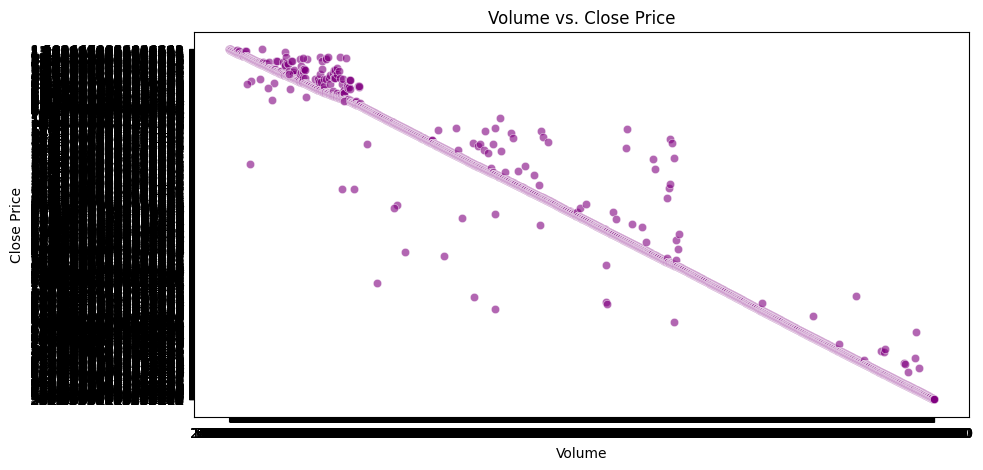

In [15]:
# 3. Volume vs. Close Price Scatter Plot
plt.figure(figsize=(10, 5))
sns.scatterplot(x=df['Volume'], y=df['Close'], color="purple", alpha=0.6)
plt.title("Volume vs. Close Price")
plt.xlabel("Volume")
plt.ylabel("Close Price")
plt.show()

In [16]:
df["Date"]=pd.to_datetime(df["Date"])
df.set_index("Date",inplace=True)
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df["Close"]=le.fit_transform(df["Close"])
df["High"]=le.fit_transform(df["High"])
df["Low"]=le.fit_transform(df["Low"])
df["Open"]=le.fit_transform(df["Open"])
df["Volume"]=le.fit_transform(df["Volume"])


<Axes: xlabel='Date', ylabel='Close'>

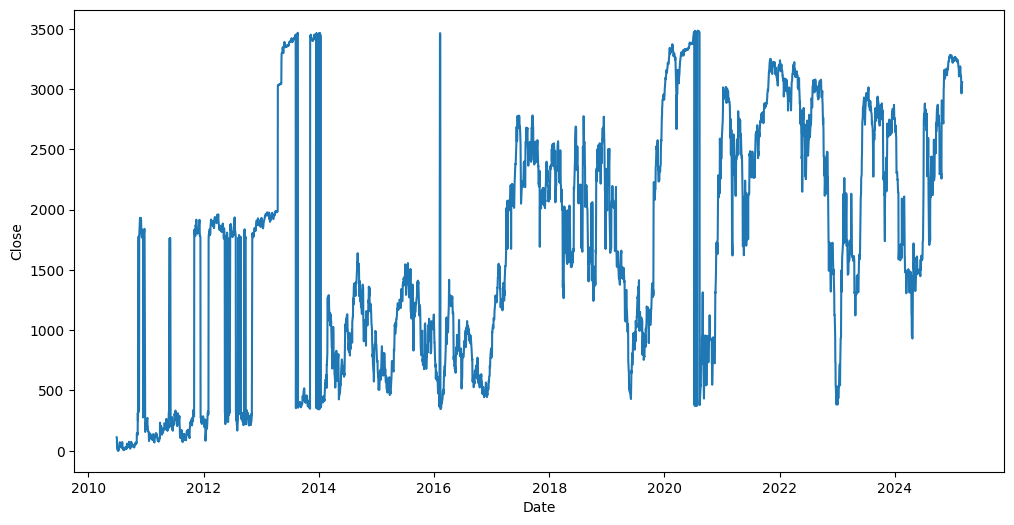

In [17]:
plt.figure(figsize=(12,6))
sns.lineplot(x="Date",y="Close",data=df)

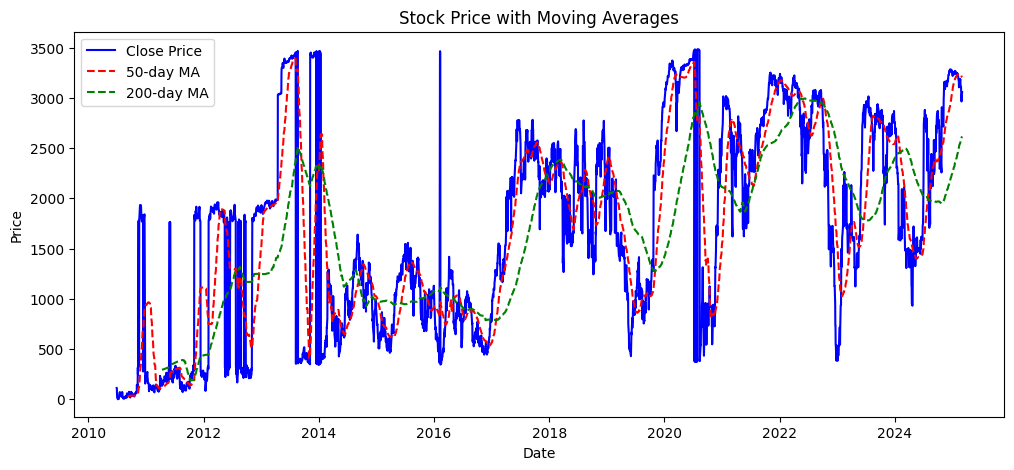

In [18]:
# 4. Moving Averages
df["50_MA"] = df["Close"].rolling(window=50).mean()
df["200_MA"] = df["Close"].rolling(window=200).mean()

plt.figure(figsize=(12, 5))
plt.plot(df.index, df["Close"], label="Close Price", color="blue")
plt.plot(df.index, df["50_MA"], label="50-day MA", color="red", linestyle="dashed")
plt.plot(df.index, df["200_MA"], label="200-day MA", color="green", linestyle="dashed")
plt.legend()
plt.title("Stock Price with Moving Averages")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

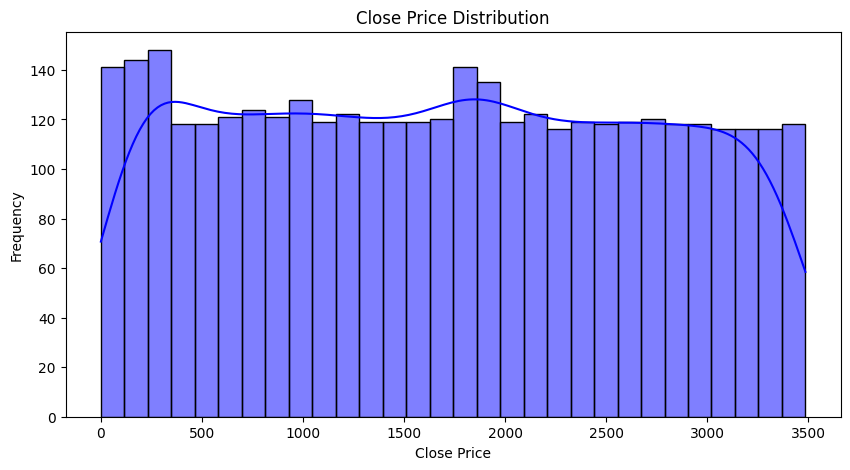

In [19]:
# 5. Histogram for Price Distribution
plt.figure(figsize=(10, 5))
sns.histplot(df["Close"], bins=30, kde=True, color="blue")
plt.title("Close Price Distribution")
plt.xlabel("Close Price")
plt.ylabel("Frequency")
plt.show()

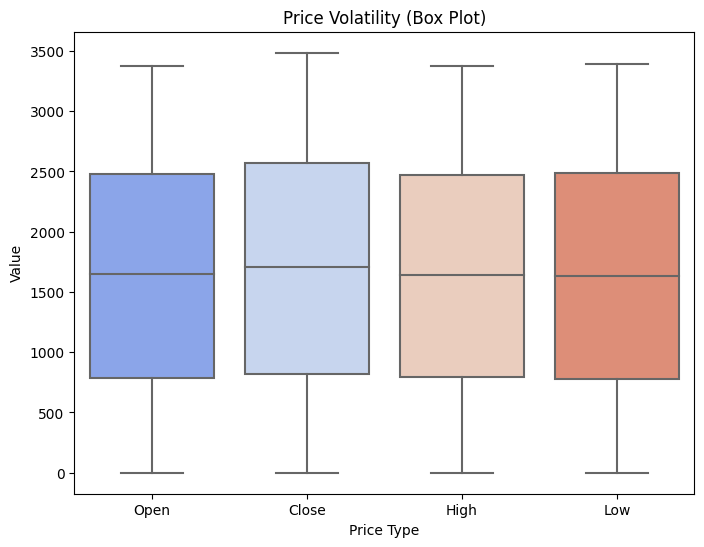

In [20]:
# 6. Box Plot for Price Volatility
plt.figure(figsize=(8, 6))
sns.boxplot(data=df[['Open', 'Close', 'High', 'Low']], palette="coolwarm")
plt.title("Price Volatility (Box Plot)")
plt.xlabel("Price Type")
plt.ylabel("Value")
plt.show()

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
import xgboost as xgb

In [22]:
df.columns

Index(['Close', 'High', 'Low', 'Open', 'Volume', '50_MA', '200_MA'], dtype='object')

In [23]:
# Ensure 'Date' is in datetime format (if applicable)
if 'Date' in df.columns:
    df["Date"] = pd.to_datetime(df["Date"])
    df.set_index("Date", inplace=True)  # Set 'Date' as index

In [24]:
# Check for missing values
df.fillna(df.median(), inplace=True)  # Fill missing values with median

In [25]:
# Label Encoding (if needed)
le = LabelEncoder()
for col in df.columns:
    df[col] = le.fit_transform(df[col])


In [26]:
# Splitting features and target variable
X = df.drop("Close", axis=1)  # Features
y = df["Close"]  

In [27]:
# Train-Test Split (80-20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [28]:
# Standardize Data (Optional, required for some models)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [29]:
# Define ML models
models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "SVM": SVC(),
}

In [30]:
# Train & Evaluate Models
results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    results[name] = accuracy_score(y_test, y_pred)

# Print Summary
print("\nModel Performance Summary:")
for name, acc in results.items():
    print(f"{name}: {acc:.4f}")



Model Performance Summary:
Logistic Regression: 0.0000
Decision Tree: 0.0027
Random Forest: 0.0027
SVM: 0.0000


## THank you...pls upvote